In [12]:
import os
import re
import gc
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image, ImageFile

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.model_selection import train_test_split

torch.backends.cudnn.enabled = False

ImageFile.LOAD_TRUNCATED_IMAGES = True

# 16 development phases
PHASES = [
    "tPB2", "tPNa", "tPNf", "t2", "t3", "t4", "t5", "t6",
    "t7", "t8", "t9+", "tM", "tSB", "tB", "tEB", "tHB",
]
PHASE_TO_IDX = {p: i for i, p in enumerate(PHASES)}
NUM_CLASSES = len(PHASES)

BASE_DIR = Path.cwd()
IMG_DIR = BASE_DIR / "embryo_dataset"
ANNO_DIR = BASE_DIR / "embryo_dataset_annotations"
OUT_DIR = BASE_DIR / "outputs_lstm"
CKPT_DIR = BASE_DIR / "checkpoints_lstm"
OUT_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)

assert IMG_DIR.exists(), f"IMG_DIR not found: {IMG_DIR}"
assert ANNO_DIR.exists(), f"ANNO_DIR not found: {ANNO_DIR}"

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Python:', os.sys.version.split()[0])
print('Torch:', torch.__version__)
print('Using device:', device)
if device.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))

Python: 3.10.20
Torch: 2.5.1
Using device: cuda
GPU: NVIDIA GeForce RTX 3070 Ti Laptop GPU


In [13]:
RUN_RE = re.compile(r"_RUN(\d+)\.(?:jpe?g|png)$", re.IGNORECASE)

def _run_number(filename: str) -> int | None:
    m = RUN_RE.search(filename)
    return int(m.group(1)) if m else None

class EmbryoSequenceDataset(Dataset):
    def __init__(self, img_dir, anno_dir, video_ids, transform=None, seq_len=5, sample_rate=1):
        self.img_dir = Path(img_dir)
        self.anno_dir = Path(anno_dir)
        self.video_ids = list(video_ids)
        self.transform = transform
        self.seq_len = seq_len
        self.sample_rate = sample_rate
        self.samples, self.video_frame_maps = self._prepare_samples()

    def _prepare_samples(self):
        samples = []
        video_frame_maps = {} 
        
        for vid in self.video_ids:
            csv_path = self.anno_dir / f"{vid}_phases.csv"
            vid_folder = self.img_dir / vid

            if (not csv_path.exists()) or (not vid_folder.exists()): continue

            run_to_path = {}
            for f in os.listdir(vid_folder):
                rn = _run_number(f)
                if rn is not None: run_to_path[rn] = str(vid_folder / f)

            if not run_to_path: continue
            video_frame_maps[vid] = run_to_path

            df = pd.read_csv(csv_path, header=None)
            for _, row in df.iterrows():
                phase_name = str(row.iloc[0]).strip()
                if phase_name not in PHASE_TO_IDX: continue
                label = PHASE_TO_IDX[phase_name]
                start_run, end_run = int(row.iloc[1]), int(row.iloc[2])

                for run in range(start_run, end_run + 1, self.sample_rate):
                    if run in run_to_path:
                        # Store target run, label, and video ID
                        samples.append((vid, run, label))

        return samples, video_frame_maps

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        vid, target_run, label = self.samples[idx]
        run_to_path = self.video_frame_maps[vid]
        
        sequence_images = []
        # Build the sequence looking backwards in time
        for step in range(self.seq_len - 1, -1, -1):
            lookback_run = target_run - step
            
            # If early frames don't exist, clamp to the earliest available frame
            while lookback_run not in run_to_path and lookback_run < target_run:
                lookback_run += 1
                
            img_path = run_to_path.get(lookback_run, run_to_path[target_run])
            
            image = Image.open(img_path).convert("RGB")
            if self.transform: image = self.transform(image)
            sequence_images.append(image)
            
        # Stack 2D images into a 3D Tensor: (Seq_Len, Channels, Height, Width)
        seq_tensor = torch.stack(sequence_images)
        return seq_tensor, torch.tensor(label, dtype=torch.long)

In [14]:
class Embryo_CNN_LSTM(nn.Module):
    def __init__(self, num_classes=16, lstm_hidden=256, lstm_layers=1):
        super(Embryo_CNN_LSTM, self).__init__()
        
        # 1. The CNN Feature Extractor (Frozen to save VRAM)
        self.cnn = models.mobilenet_v2(weights='DEFAULT')
        for param in self.cnn.parameters():
            param.requires_grad = False
            
        # Remove the classification head, keep the feature extractor
        cnn_out_features = self.cnn.classifier[1].in_features
        self.cnn.classifier = nn.Identity() 
        
        # 2. The LSTM Sequence Modeler
        self.lstm = nn.LSTM(
            input_size=cnn_out_features, 
            hidden_size=lstm_hidden, 
            num_layers=lstm_layers, 
            batch_first=True,     # Ensures input is (Batch, Sequence, Features)
            dropout=0.2 if lstm_layers > 1 else 0
    )
        
        # 3. Final Classification Head
        self.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(lstm_hidden, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # Incoming x shape: (Batch, Seq_Len, Channels, Height, Width)
        batch_size, seq_len, c, h, w = x.size()
        
        # Reshape to process all frames through the CNN at once
        x = x.view(batch_size * seq_len, c, h, w)
        cnn_features = self.cnn(x)
        
        # Reshape back to sequence format for LSTM
        lstm_in = cnn_features.view(batch_size, seq_len, -1)
        
        # Pass through LSTM
        lstm_out, (hidden, cell) = self.lstm(lstm_in)
        
        # We only care about the LSTM's output at the final time step
        final_timestep = lstm_out[:, -1, :] 
        
        logits = self.fc(final_timestep)
        return logits

In [15]:
# Spec requirements:
# - Component 1: CrossEntropy
# - Component 2: CDF SmoothL1 loss (EMD-equivalent)
# - Beta warmup: epoch 1 -> beta=0; ramp over next 2 epochs to BETA_MAX=0.30

BETA_MAX = 0.30
WARMUP_EPOCHS = 1   # epoch 0 => beta 0
RAMP_EPOCHS = 2     # epochs 1..2 ramp to BETA_MAX

def beta_schedule(epoch_idx: int) -> float:
    # epoch_idx is 0-based
    if epoch_idx < WARMUP_EPOCHS:
        return 0.0
    if RAMP_EPOCHS <= 0:
        return float(BETA_MAX)
    # linearly ramp for the next RAMP_EPOCHS epochs
    t = (epoch_idx - WARMUP_EPOCHS + 1) / float(RAMP_EPOCHS)
    t = max(0.0, min(1.0, t))
    return float(BETA_MAX) * t

def ordinal_cdf_smoothl1_loss_from_logits(logits: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    # logits: [B,C], y: [B] long
    probs = F.softmax(logits, dim=1)
    b, c = probs.shape
    y = y.long()
    target = F.one_hot(y, num_classes=c).to(dtype=probs.dtype)  # [B,C]

    # CDFs
    cdf_pred = probs.cumsum(dim=1)
    cdf_true = target.cumsum(dim=1)
    diff = cdf_pred - cdf_true

    # SmoothL1 on CDF differences (stable, distance-aware)
    return F.smooth_l1_loss(diff, torch.zeros_like(diff))

def hybrid_chrono_loss(logits: torch.Tensor, y: torch.Tensor, epoch_idx: int) -> tuple[torch.Tensor, float, float, float]:
    # Returns: total_loss, ce_loss, ord_loss, beta
    ce = F.cross_entropy(logits, y.long())
    ord_term = ordinal_cdf_smoothl1_loss_from_logits(logits, y)
    beta = beta_schedule(epoch_idx)
    total = ce + beta * ord_term
    return total, float(ce.item()), float(ord_term.item()), float(beta)

In [16]:
import json
from math import ceil
from pathlib import Path
from torch.utils.data import Subset


# - Keep a fixed 70/15/15 split at VIDEO level (val/test fixed)
# - Train is broken into sequential stages, each covering ~8% of TOTAL videos
# - Each stage saves checkpoint+state and bootstraps the next stage
# - After ALL stages: run final validation + test evaluation
# - Optional speed cap: ~3000 train steps/epoch via a saved subset of frame-samples


DEVICE = device
SAMPLE_RATE = 1
IMAGE_SIZE = 224
SEQ_LEN = 5
BATCH_SIZE = 8
LR = 5e-4
WEIGHT_DECAY = 0.0
NUM_EPOCHS_PER_STAGE = 5
PRINT_EVERY_STEPS = 50

# 1) Stage sizing controls

TRAIN_SPLIT = 0.70
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15

# Requested: each stage is ~8% of TOTAL videos (video-level)
STAGE_TOTAL_VIDEO_FRACTION = 0.08  # 8%
SPLIT_SEED = 42

# Speed control (sample-level)
LIMIT_TRAIN_STEPS = True
TARGET_TRAIN_STEPS = 3000
SUBSET_SEED = 42

# Execution control
AUTO_RUN_ALL_STAGES = True
STAGE_TO_RUN = 1  # used only if AUTO_RUN_ALL_STAGES=False (1-based)

# 2) Output paths
OUT_DIR.mkdir(parents=True, exist_ok=True)
split_dir = OUT_DIR / 'splits'
subset_dir = OUT_DIR / 'subsets'
split_dir.mkdir(parents=True, exist_ok=True)
subset_dir.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = str(OUT_DIR / 'best_cnn_lstm.pth')  # global best weights-only

# 3) Transforms
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=90),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# 4) Split videos (70/15/15)
all_vids = sorted([p.name for p in IMG_DIR.iterdir() if p.is_dir()])
assert len(all_vids) > 0, f'No videos found under IMG_DIR: {IMG_DIR}'

train_vids, temp_vids = train_test_split(
    all_vids,
    test_size=(1.0 - TRAIN_SPLIT),
    random_state=SPLIT_SEED,
    shuffle=True,
)
val_vids, test_vids = train_test_split(
    temp_vids,
    test_size=TEST_SPLIT / (VAL_SPLIT + TEST_SPLIT),
    random_state=SPLIT_SEED,
    shuffle=True,
)

print(f'Video split -> Train: {len(train_vids)} | Val: {len(val_vids)} | Test: {len(test_vids)}', flush=True)

(split_dir / 'train_vids.txt').write_text('\n'.join(train_vids))
(split_dir / 'val_vids.txt').write_text('\n'.join(val_vids))
(split_dir / 'test_vids.txt').write_text('\n'.join(test_vids))

# 5) Make stage lists (each stage ≈ 8% of TOTAL videos)
stage_size_vids = int(round(STAGE_TOTAL_VIDEO_FRACTION * len(all_vids)))
stage_size_vids = max(1, stage_size_vids)

rng = np.random.default_rng(SPLIT_SEED)
perm = rng.permutation(len(train_vids))
shuffled_train_vids = [train_vids[i] for i in perm]

stage_vid_lists: list[list[str]] = []
for start in range(0, len(shuffled_train_vids), stage_size_vids):
    stage_vid_lists.append(shuffled_train_vids[start : start + stage_size_vids])

num_stages = len(stage_vid_lists)
print(
    f'Staging -> stage_size_vids={stage_size_vids} (~{STAGE_TOTAL_VIDEO_FRACTION:.0%} of total videos) | '
    f'num_stages={num_stages} to cover {len(train_vids)} train videos',
    flush=True,
 )

# Save stage video lists for reproducibility
for idx, vids in enumerate(stage_vid_lists, start=1):
    (split_dir / f'train_stage_{idx:02d}_vids.txt').write_text('\n'.join(vids))
print(f'✅ Saved video splits (incl. stages) to: {split_dir}', flush=True)

stages_to_run = list(range(1, num_stages + 1)) if AUTO_RUN_ALL_STAGES else [int(STAGE_TO_RUN)]
assert all(1 <= s <= num_stages for s in stages_to_run), f'Invalid stage(s): {stages_to_run} with num_stages={num_stages}'

# 6) Helpers
def _diagnose_empty_train(video_ids: list[str]):
    print('❌ Train dataset has 0 samples. Common causes:', flush=True)
    print('  - ANNO_DIR path is wrong or CSVs are missing', flush=True)
    print('  - CSV RUN ranges do not match your frame RUN numbers', flush=True)
    print('  - Frame filenames do not match *_RUN<number>.jpg', flush=True)
    sample_vids = video_ids[:10]
    for vid in sample_vids:
        csv_path = ANNO_DIR / f'{vid}_phases.csv'
        vid_folder = IMG_DIR / vid
        if not csv_path.exists():
            print(f'  - Missing CSV: {csv_path}', flush=True)
        if not vid_folder.exists():
            print(f'  - Missing frames folder: {vid_folder}', flush=True)
    raise ValueError('Train dataset is empty; fix paths/filenames/annotations and re-run.')

def tol_accuracy_from_logits(logits: torch.Tensor, y: torch.Tensor, tol: int = 1) -> float:
    preds = torch.argmax(logits, dim=1)
    return float((torch.abs(preds - y.long()) <= tol).float().mean().item())

def _load_or_make_subset_indices(*, stage_idx: int, dataset_len: int) -> tuple[list[int] | None, str | None]:
    if not LIMIT_TRAIN_STEPS:
        return None, None
    if TARGET_TRAIN_STEPS <= 0:
        raise ValueError('TARGET_TRAIN_STEPS must be > 0 when LIMIT_TRAIN_STEPS=True')
    target_samples = int(TARGET_TRAIN_STEPS) * int(BATCH_SIZE)
    n = min(int(dataset_len), int(target_samples))
    if n <= 0:
        return None, None

    subset_path = subset_dir / f'train_subset_indices_stage{stage_idx:02d}_n{n}_seed{SUBSET_SEED}.npy'
    meta_path = subset_dir / f'train_subset_meta_stage{stage_idx:02d}_n{n}_seed{SUBSET_SEED}.json'

    idx = None
    if subset_path.exists():
        try:
            idx = np.load(subset_path).astype(np.int64)
            if idx.ndim != 1 or int(idx.shape[0]) != n:
                idx = None
            elif idx.max(initial=-1) >= dataset_len or idx.min(initial=0) < 0:
                idx = None
        except Exception:
            idx = None

    if idx is None:
        rng = np.random.default_rng(int(SUBSET_SEED) + int(stage_idx) * 1000)
        idx = rng.choice(dataset_len, size=n, replace=False).astype(np.int64)
        np.save(subset_path, idx)
        meta = {
            'stage_idx': int(stage_idx),
            'dataset_len': int(dataset_len),
            'subset_len': int(n),
            'batch_size': int(BATCH_SIZE),
            'target_train_steps': int(TARGET_TRAIN_STEPS),
            'seed': int(SUBSET_SEED),
        }
        meta_path.write_text(json.dumps(meta, indent=2))
        print(f'✅ Created & saved fixed train subset: {subset_path} ({n} samples)', flush=True)
    else:
        print(f'✅ Loaded fixed train subset: {subset_path} ({len(idx)} samples)', flush=True)

    return idx.tolist(), str(subset_path)

def _evaluate_loader(model: nn.Module, loader: DataLoader, epoch_idx_for_beta: int) -> tuple[float, float, float, float]:
    # returns: total_loss, ce_loss, ord_loss, tol_acc(±1)
    model.eval()
    total_sum = 0.0
    ce_sum = 0.0
    ord_sum = 0.0
    tol_sum = 0.0
    n = 0
    with torch.no_grad():
        for sequences, labels in loader:
            sequences = sequences.to(DEVICE)
            y = labels.view(-1).long().to(DEVICE)
            logits = model(sequences)
            loss, ce_val, ord_val, _beta_val = hybrid_chrono_loss(logits, y, epoch_idx=epoch_idx_for_beta)
            bs = int(y.size(0))
            n += bs
            total_sum += float(loss.item()) * bs
            ce_sum += float(ce_val) * bs
            ord_sum += float(ord_val) * bs
            tol_sum += tol_accuracy_from_logits(logits, y, tol=1) * bs
            del sequences, labels, y, logits, loss
    if n == 0:
        return float('nan'), float('nan'), float('nan'), float('nan')
    return total_sum / n, ce_sum / n, ord_sum / n, tol_sum / n

# 7) Training across stages
stage_results = []
history = {
    'train_total': [], 'train_ce': [], 'train_ord': [], 'train_tol_acc': [],
    'val_total': [], 'val_ce': [], 'val_ord': [], 'val_tol_acc': [],
    'stage_idx': [], 'stage_epoch': [], 'global_epoch': [], 'beta': [],
}

global_best_val = float('inf')
global_epoch_next = 0  # 0-based counter across ALL stages
last_stage_checkpoint_path = None

# Val/Test fixed across all stages
val_dataset = EmbryoSequenceDataset(IMG_DIR, ANNO_DIR, val_vids, transform=val_test_transforms, seq_len=SEQ_LEN, sample_rate=SAMPLE_RATE)
test_dataset = EmbryoSequenceDataset(IMG_DIR, ANNO_DIR, test_vids, transform=val_test_transforms, seq_len=SEQ_LEN, sample_rate=SAMPLE_RATE)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print(f'Val/Test samples -> Val: {len(val_dataset)} | Test: {len(test_dataset)}', flush=True)

for stage_idx in stages_to_run:
    active_train_vids = stage_vid_lists[stage_idx - 1]
    stage_name = f'stage{stage_idx:02d}'
    latest_ckpt = str(OUT_DIR / f'latest_checkpoint_{stage_name}.pth')
    prev_ckpt = last_stage_checkpoint_path  # bootstrap source (previous stage)

    print(f'\n==================== RUNNING {stage_name} ({stage_idx}/{num_stages}) ====================\n', flush=True)
    print(f'Active train videos: {len(active_train_vids)}', flush=True)

    train_dataset_full = EmbryoSequenceDataset(IMG_DIR, ANNO_DIR, active_train_vids, transform=train_transforms, seq_len=SEQ_LEN, sample_rate=SAMPLE_RATE)
    if len(train_dataset_full) == 0:
        _diagnose_empty_train(active_train_vids)

    subset_indices, subset_path = _load_or_make_subset_indices(stage_idx=stage_idx, dataset_len=len(train_dataset_full))
    if subset_indices is not None:
        train_dataset = Subset(train_dataset_full, subset_indices)
    else:
        train_dataset = train_dataset_full

    effective_steps = int(ceil(len(train_dataset) / float(BATCH_SIZE)))
    print(f'Train samples -> full={len(train_dataset_full)} | used={len(train_dataset)} => ~{effective_steps} steps/epoch', flush=True)
    if subset_path is not None:
        print(f'LIMIT_TRAIN_STEPS=True -> TARGET_TRAIN_STEPS={TARGET_TRAIN_STEPS} | subset_file={subset_path}', flush=True)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

    # Construct fresh objects, then load state as needed
    model = Embryo_CNN_LSTM().to(DEVICE)
    trainable_params = filter(lambda p: p.requires_grad, model.parameters())
    optimizer = optim.Adam(trainable_params, lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

    start_stage_epoch = 0
    # Resume priority: current stage checkpoint -> else bootstrap from previous stage checkpoint (model+optim+sched+history+global_epoch)
    if os.path.exists(latest_ckpt):
        print(f'📥 Resume: found {latest_ckpt}, loading…', flush=True)
        ckpt = torch.load(latest_ckpt, map_location=DEVICE)
        model.load_state_dict(ckpt['model_state_dict'])
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        scheduler.load_state_dict(ckpt['scheduler_state_dict'])
        start_stage_epoch = int(ckpt.get('stage_epoch_next', ckpt.get('stage_epoch', 0)))
        global_epoch_next = int(ckpt.get('global_epoch_next', global_epoch_next))
        global_best_val = float(ckpt.get('global_best_val', global_best_val))
        if isinstance(ckpt.get('history', None), dict):
            history = ckpt['history']
        print(f'✅ Resumed {stage_name} at stage_epoch={start_stage_epoch} | global_epoch_next={global_epoch_next} | global_best_val={global_best_val:.6f}', flush=True)
    elif prev_ckpt is not None and os.path.exists(prev_ckpt):
        print(f'📥 Bootstrap: loading previous stage state from {prev_ckpt}', flush=True)
        ckpt = torch.load(prev_ckpt, map_location=DEVICE)
        model.load_state_dict(ckpt['model_state_dict'])
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        scheduler.load_state_dict(ckpt['scheduler_state_dict'])
        global_epoch_next = int(ckpt.get('global_epoch_next', global_epoch_next))
        global_best_val = float(ckpt.get('global_best_val', global_best_val))
        if isinstance(ckpt.get('history', None), dict):
            history = ckpt['history']
        start_stage_epoch = 0
        print(f'✅ Bootstrapped into {stage_name} with global_epoch_next={global_epoch_next} | global_best_val={global_best_val:.6f}', flush=True)
    else:
        print('Starting fresh (no checkpoint found to resume/bootstrap).', flush=True)

    # ---- Epoch loop (within this stage) ----
    for stage_epoch in range(start_stage_epoch, NUM_EPOCHS_PER_STAGE):
        global_epoch = int(global_epoch_next)  # current epoch index (0-based)
        beta = beta_schedule(global_epoch)

        # Train
        model.train()
        tr_total_sum = 0.0
        tr_ce_sum = 0.0
        tr_ord_sum = 0.0
        tr_tol_sum = 0.0
        tr_n = 0

        for step_i, (sequences, labels) in enumerate(train_loader):
            sequences = sequences.to(DEVICE)
            y = labels.view(-1).long().to(DEVICE)

            optimizer.zero_grad(set_to_none=True)
            logits = model(sequences)
            loss, ce_val, ord_val, beta_val = hybrid_chrono_loss(logits, y, epoch_idx=global_epoch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            bs = int(y.size(0))
            tr_n += bs
            tr_total_sum += float(loss.item()) * bs
            tr_ce_sum += float(ce_val) * bs
            tr_ord_sum += float(ord_val) * bs
            tr_tol_sum += tol_accuracy_from_logits(logits.detach(), y, tol=1) * bs

            if PRINT_EVERY_STEPS and (step_i + 1) % int(PRINT_EVERY_STEPS) == 0:
                print(
                    f'[{stage_name}] epoch {stage_epoch+1}/{NUM_EPOCHS_PER_STAGE} | global {global_epoch+1} | step {step_i+1}/{len(train_loader)} | '
                    f'total {loss.item():.4f} (ce {ce_val:.4f} + {beta_val:.3f}*ord {ord_val:.4f})',
                    flush=True,
                )

            del sequences, labels, y, logits, loss

        train_total = tr_total_sum / max(1, tr_n)
        train_ce = tr_ce_sum / max(1, tr_n)
        train_ord = tr_ord_sum / max(1, tr_n)
        train_tol = tr_tol_sum / max(1, tr_n)

        # Val (full val set)
        val_total, val_ce, val_ord, val_tol = _evaluate_loader(model, val_loader, epoch_idx_for_beta=global_epoch)
        scheduler.step(val_total)

        # Track history
        history['train_total'].append(float(train_total))
        history['train_ce'].append(float(train_ce))
        history['train_ord'].append(float(train_ord))
        history['train_tol_acc'].append(float(train_tol))
        history['val_total'].append(float(val_total))
        history['val_ce'].append(float(val_ce))
        history['val_ord'].append(float(val_ord))
        history['val_tol_acc'].append(float(val_tol))
        history['stage_idx'].append(int(stage_idx))
        history['stage_epoch'].append(int(stage_epoch + 1))
        history['global_epoch'].append(int(global_epoch + 1))
        history['beta'].append(float(beta))

        # Save global best weights (weights-only)
        if val_total < global_best_val:
            global_best_val = float(val_total)
            torch.save(model.state_dict(), BEST_MODEL_PATH)
            print(f'✅ New GLOBAL best val loss {global_best_val:.6f} -> saved weights to {BEST_MODEL_PATH}', flush=True)

        # Save latest checkpoint for this stage (resume-able)
        ckpt_payload = {
            'stage_name': stage_name,
            'stage_idx': int(stage_idx),
            'num_stages': int(num_stages),
            'stage_epoch_next': int(stage_epoch + 1),
            'global_epoch_next': int(global_epoch + 1),
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'global_best_val': float(global_best_val),
            'best_model_path': str(BEST_MODEL_PATH),
            'history': history,
            'config': {
                'stage_total_video_fraction': float(STAGE_TOTAL_VIDEO_FRACTION),
                'stage_size_vids': int(stage_size_vids),
                'train_split': float(TRAIN_SPLIT),
                'val_split': float(VAL_SPLIT),
                'test_split': float(TEST_SPLIT),
                'limit_train_steps': bool(LIMIT_TRAIN_STEPS),
                'target_train_steps': int(TARGET_TRAIN_STEPS),
                'train_subset_indices_path': subset_path,
                'batch_size': int(BATCH_SIZE),
                'seq_len': int(SEQ_LEN),
                'image_size': int(IMAGE_SIZE),
                'sample_rate': int(SAMPLE_RATE),
                'lr': float(LR),
                'weight_decay': float(WEIGHT_DECAY),
                'num_epochs_per_stage': int(NUM_EPOCHS_PER_STAGE),
                'split_seed': int(SPLIT_SEED),
                'subset_seed': int(SUBSET_SEED),
            },
        }
        torch.save(ckpt_payload, latest_ckpt)

        print(
            f'--- [{stage_name}] epoch {stage_epoch+1}/{NUM_EPOCHS_PER_STAGE} | global {global_epoch+1} | beta={beta:.3f} | '
            f'Train {train_total:.4f} (ce {train_ce:.4f}, ord {train_ord:.4f}) tol {train_tol:.2%} | '
            f'Val {val_total:.4f} (ce {val_ce:.4f}, ord {val_ord:.4f}) tol {val_tol:.2%} ---',
            flush=True,
        )

        # advance global epoch counter
        global_epoch_next = int(global_epoch + 1)

    # After stage complete, this stage checkpoint becomes bootstrap source for the next stage
    last_stage_checkpoint_path = latest_ckpt
    stage_results.append({
        'stage': stage_name,
        'checkpoint': latest_ckpt,
        'global_epoch_next': int(global_epoch_next),
        'global_best_val': float(global_best_val),
    })
    print(f'✅ {stage_name} complete. Latest checkpoint: {latest_ckpt}', flush=True)

print('\n✅ All requested stages complete:', stage_results, flush=True)


# 8) Final evaluation (after ALL stages)

if os.path.exists(BEST_MODEL_PATH):
    print(f'\n Loading global best weights: {BEST_MODEL_PATH}', flush=True)
    final_model = Embryo_CNN_LSTM().to(DEVICE)
    final_model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))

    # Use last trained global epoch for beta schedule reference (safe even if 0)
    eval_epoch_idx = max(0, int(global_epoch_next) - 1)
    val_total, val_ce, val_ord, val_tol = _evaluate_loader(final_model, val_loader, epoch_idx_for_beta=eval_epoch_idx)
    test_total, test_ce, test_ord, test_tol = _evaluate_loader(final_model, test_loader, epoch_idx_for_beta=eval_epoch_idx)

    print(f'\n✅ FINAL (best weights) | Val total {val_total:.4f} (ce {val_ce:.4f}, ord {val_ord:.4f}) tol(±1) {val_tol:.2%}', flush=True)
    print(f'✅ FINAL (best weights) | Test total {test_total:.4f} (ce {test_ce:.4f}, ord {test_ord:.4f}) tol(±1) {test_tol:.2%}', flush=True)
else:
    print('⚠️ BEST_MODEL_PATH not found yet (train first).', flush=True)

Video split -> Train: 492 | Val: 106 | Test: 106
Staging -> stage_size_vids=56 (~8% of total videos) | num_stages=9 to cover 492 train videos
✅ Saved video splits (incl. stages) to: c:\Users\Swarup\Downloads\embryo_dataset\outputs_lstm\splits
Val/Test samples -> Val: 45581 | Test: 44709

==================== RUNNING stage01 (1/9) ====================

Active train videos: 56
✅ Created & saved fixed train subset: c:\Users\Swarup\Downloads\embryo_dataset\outputs_lstm\subsets\train_subset_indices_stage01_n23214_seed42.npy (23214 samples)
Train samples -> full=23214 | used=23214 => ~2902 steps/epoch
LIMIT_TRAIN_STEPS=True -> TARGET_TRAIN_STEPS=3000 | subset_file=c:\Users\Swarup\Downloads\embryo_dataset\outputs_lstm\subsets\train_subset_indices_stage01_n23214_seed42.npy
Starting fresh (no checkpoint found to resume/bootstrap).
[stage01] epoch 1/5 | global 1 | step 50/2902 | total 2.1564 (ce 2.1564 + 0.000*ord 0.0739)
[stage01] epoch 1/5 | global 1 | step 100/2902 | total 2.4987 (ce 2.4987 +

Video split -> Train: 492 | Val: 106 | Test: 106
Staging -> stage_size_vids=56 (~8% of total videos) | num_stages=9 to cover 492 train videos
✅ Saved video splits (incl. stages) to: c:\Users\Swarup\Downloads\embryo_dataset\outputs_lstm\splits
Val/Test samples -> Val: 45581 | Test: 44709

==================== RUNNING stage01 (1/9) ====================

Active train videos: 56
✅ Created & saved fixed train subset: c:\Users\Swarup\Downloads\embryo_dataset\outputs_lstm\subsets\train_subset_indices_stage01_n23214_seed42.npy (23214 samples)
Train samples -> full=23214 | used=23214 => ~2902 steps/epoch
LIMIT_TRAIN_STEPS=True -> TARGET_TRAIN_STEPS=3000 | subset_file=c:\Users\Swarup\Downloads\embryo_dataset\outputs_lstm\subsets\train_subset_indices_stage01_n23214_seed42.npy
Starting fresh (no checkpoint found to resume/bootstrap).
[stage01] epoch 1/5 | global 1 | step 50/2902 | total 2.1564 (ce 2.1564 + 0.000*ord 0.0739)
[stage01] epoch 1/5 | global 1 | step 100/2902 | total 2.4987 (ce 2.4987 +

C:\Users\Swarup\AppData\Local\Temp\ipykernel_35072\2468459204.py:273: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(prev_ckpt, map_location=DEVICE)


Video split -> Train: 492 | Val: 106 | Test: 106
Staging -> stage_size_vids=56 (~8% of total videos) | num_stages=9 to cover 492 train videos
✅ Saved video splits (incl. stages) to: c:\Users\Swarup\Downloads\embryo_dataset\outputs_lstm\splits
Val/Test samples -> Val: 45581 | Test: 44709

==================== RUNNING stage01 (1/9) ====================

Active train videos: 56
✅ Created & saved fixed train subset: c:\Users\Swarup\Downloads\embryo_dataset\outputs_lstm\subsets\train_subset_indices_stage01_n23214_seed42.npy (23214 samples)
Train samples -> full=23214 | used=23214 => ~2902 steps/epoch
LIMIT_TRAIN_STEPS=True -> TARGET_TRAIN_STEPS=3000 | subset_file=c:\Users\Swarup\Downloads\embryo_dataset\outputs_lstm\subsets\train_subset_indices_stage01_n23214_seed42.npy
Starting fresh (no checkpoint found to resume/bootstrap).
[stage01] epoch 1/5 | global 1 | step 50/2902 | total 2.1564 (ce 2.1564 + 0.000*ord 0.0739)
[stage01] epoch 1/5 | global 1 | step 100/2902 | total 2.4987 (ce 2.4987 +

C:\Users\Swarup\AppData\Local\Temp\ipykernel_35072\2468459204.py:273: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(prev_ckpt, map_location=DEVICE)


...

[stage08] epoch 1/5 | global 36 | step 50/2973 | total 1.0744 (ce 1.0702 + 0.300*ord 0.0139)
[stage08] epoch 1/5 | global 36 | step 100/2973 | total 1.0139 (ce 1.0098 + 0.300*ord 0.0136)
[stage08] epoch 1/5 | global 36 | step 150/2973 | total 2.0306 (ce 2.0223 + 0.300*ord 0.0278)
[stage08] epoch 1/5 | global 36 | step 200/2973 | total 1.1621 (ce 1.1564 + 0.300*ord 0.0190)
[stage08] epoch 1/5 | global 36 | step 250/2973 | total 1.0879 (ce 1.0827 + 0.300*ord 0.0173)
[stage08] epoch 1/5 | global 36 | step 300/2973 | total 1.4868 (ce 1.4800 + 0.300*ord 0.0224)
[stage08] epoch 1/5 | global 36 | step 350/2973 | total 0.7698 (ce 0.7671 + 0.300*ord 0.0091)
[stage08] epoch 1/5 | global 36 | step 400/2973 | total 0.5720 (ce 0.5697 + 0.300*ord 0.0077)
[stage08] epoch 1/5 | global 36 | step 450/2973 | total 0.9449 (ce 0.9409 + 0.300*ord 0.0135)
[stage08] epoch 1/5 | global 36 | step 500/2973 | total 1.5054 (ce 1.5001 + 0.300*ord 0.0177)
[stage08] epoch 1/5 | global 36 | step 550/2973 | total 0.811

C:\Users\Swarup\AppData\Local\Temp\ipykernel_35072\2468459204.py:273: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(prev_ckpt, map_location=DEVICE)


[stage09] epoch 1/5 | global 41 | step 50/2284 | total 1.8392 (ce 1.8267 + 0.300*ord 0.0416)
[stage09] epoch 1/5 | global 41 | step 100/2284 | total 1.2766 (ce 1.2693 + 0.300*ord 0.0245)
[stage09] epoch 1/5 | global 41 | step 150/2284 | total 1.8814 (ce 1.8724 + 0.300*ord 0.0301)
[stage09] epoch 1/5 | global 41 | step 200/2284 | total 2.0779 (ce 2.0645 + 0.300*ord 0.0447)
[stage09] epoch 1/5 | global 41 | step 250/2284 | total 2.2636 (ce 2.2514 + 0.300*ord 0.0406)
[stage09] epoch 1/5 | global 41 | step 300/2284 | total 1.1404 (ce 1.1368 + 0.300*ord 0.0119)
[stage09] epoch 1/5 | global 41 | step 350/2284 | total 1.2602 (ce 1.2535 + 0.300*ord 0.0225)
[stage09] epoch 1/5 | global 41 | step 400/2284 | total 1.1621 (ce 1.1569 + 0.300*ord 0.0173)
[stage09] epoch 1/5 | global 41 | step 450/2284 | total 1.7558 (ce 1.7450 + 0.300*ord 0.0359)
[stage09] epoch 1/5 | global 41 | step 500/2284 | total 0.6585 (ce 0.6558 + 0.300*ord 0.0089)
[stage09] epoch 1/5 | global 41 | step 550/2284 | total 1.359

C:\Users\Swarup\AppData\Local\Temp\ipykernel_35072\2468459204.py:418: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  final_model.load_state_dict(torch.load(BEST_MODEL_PATH, m


✅ FINAL (best weights) | Val total 1.6859 (ce 1.6768, ord 0.0305) tol(±1) 66.54%
✅ FINAL (best weights) | Test total 1.8486 (ce 1.8384, ord 0.0340) tol(±1) 64.64%


✅ Using in-memory history


✅ Using in-memory history


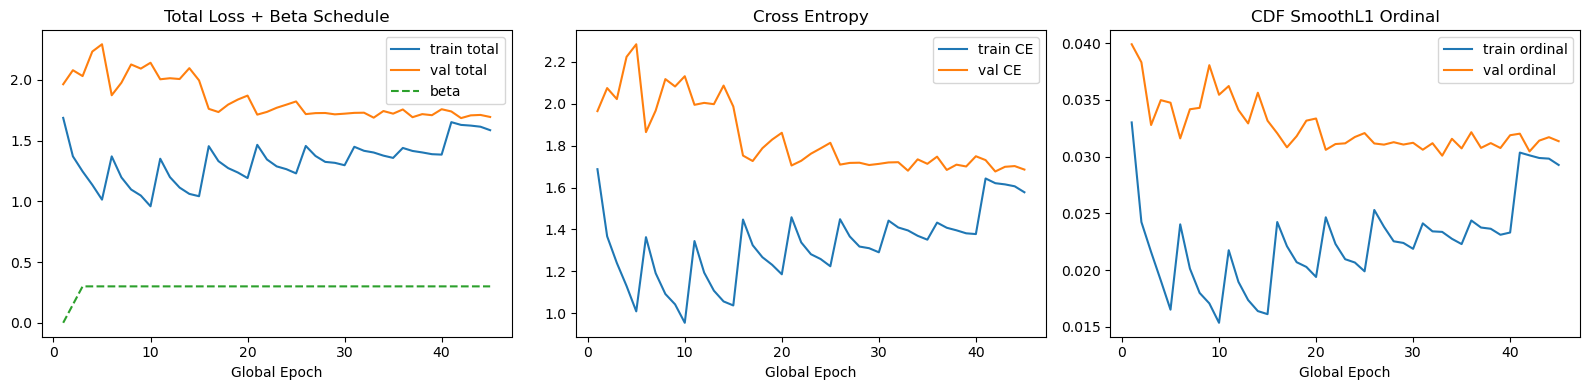

In [17]:
# --- Diagnostics plots: total/CE/ordinal + beta schedule ---
# Works even after a kernel restart by loading history from the latest stage checkpoint.
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import torch

def _find_latest_stage_checkpoint() -> str | None:
    out_dir = Path('./outputs_lstm')
    if not out_dir.exists():
        return None
    ckpts = sorted(out_dir.glob('latest_checkpoint_stage*.pth'))
    if not ckpts:
        return None
    # Prefer highest stage index if names are stage01, stage02, ...
    return str(ckpts[-1])

def _try_load_history() -> dict | None:
    # Prefer in-memory history if present
    if 'history' in globals() and isinstance(history, dict) and len(history.get('train_total', [])) > 0:
        print('✅ Using in-memory history', flush=True)
        return history

    ckpt_path = _find_latest_stage_checkpoint()
    if ckpt_path is None:
        return None
    try:
        ckpt = torch.load(ckpt_path, map_location='cpu')
        hist = ckpt.get('history', None)
        if isinstance(hist, dict) and len(hist.get('train_total', [])) > 0:
            print(f'✅ Loaded history from {ckpt_path} (stage={ckpt.get("stage_name", "?")})', flush=True)
            return hist
    except Exception as e:
        print(f'⚠️ Could not load history: {e}', flush=True)
    return None

history = _try_load_history()
if history is None:
    raise RuntimeError('No training history found. Run Cell 5 at least once (or ensure outputs_lstm/latest_checkpoint_stage*.pth exists).')

epochs = np.arange(1, len(history['train_total']) + 1)
betas = history.get('beta', None)
if not isinstance(betas, list) or len(betas) != len(epochs):
    # fallback if older checkpoint format
    betas = [beta_schedule(e - 1) for e in epochs]

plt.figure(figsize=(16, 4))

# Panel 1: total loss + beta
plt.subplot(1, 3, 1)
plt.plot(epochs, history['train_total'], label='train total')
plt.plot(epochs, history['val_total'], label='val total')
plt.plot(epochs, betas, '--', label='beta')
plt.title('Total Loss + Beta Schedule')
plt.xlabel('Global Epoch')
plt.legend()

# Panel 2: CE component
plt.subplot(1, 3, 2)
plt.plot(epochs, history['train_ce'], label='train CE')
plt.plot(epochs, history['val_ce'], label='val CE')
plt.title('Cross Entropy')
plt.xlabel('Global Epoch')
plt.legend()

# Panel 3: Ordinal component
plt.subplot(1, 3, 3)
plt.plot(epochs, history['train_ord'], label='train ordinal')
plt.plot(epochs, history['val_ord'], label='val ordinal')
plt.title('CDF SmoothL1 Ordinal')
plt.xlabel('Global Epoch')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# --- Final Test Set Evaluation (Fast Submission Mode: 5-10 min target) ---
import json
from pathlib import Path

import numpy as np
import torch
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Subset
from torchvision import transforms

# ----------------------------------------------------------
# Safety: this cell can run after kernel restart
# ----------------------------------------------------------
missing = [
    name for name in ('EmbryoSequenceDataset', 'Embryo_CNN_LSTM', 'hybrid_chrono_loss')
    if name not in globals()
]
if missing:
    raise RuntimeError(
        f"Missing required symbols: {missing}. Run Cells 1-4 first, then re-run this final evaluation cell."
    )

# Pull config from notebook globals when present; else use safe defaults
DEVICE = globals().get('DEVICE', globals().get('device', torch.device('cuda' if torch.cuda.is_available() else 'cpu')))
BATCH_SIZE = int(globals().get('BATCH_SIZE', 8))
TRAIN_SPLIT = float(globals().get('TRAIN_SPLIT', 0.70))
VAL_SPLIT = float(globals().get('VAL_SPLIT', 0.15))
TEST_SPLIT = float(globals().get('TEST_SPLIT', 0.15))
SPLIT_SEED = int(globals().get('SPLIT_SEED', 42))
IMAGE_SIZE = int(globals().get('IMAGE_SIZE', 224))
SEQ_LEN = int(globals().get('SEQ_LEN', 5))
SAMPLE_RATE = int(globals().get('SAMPLE_RATE', 1))

BASE_DIR = Path.cwd()
IMG_DIR = Path(globals().get('IMG_DIR', BASE_DIR / 'embryo_dataset'))
ANNO_DIR = Path(globals().get('ANNO_DIR', BASE_DIR / 'embryo_dataset_annotations'))
OUT_DIR = Path(globals().get('OUT_DIR', BASE_DIR / 'outputs_lstm'))
OUT_DIR.mkdir(parents=True, exist_ok=True)
BEST_MODEL_PATH = str(globals().get('BEST_MODEL_PATH', OUT_DIR / 'best_cnn_lstm.pth'))

# ==========================================================
# Fast-mode knobs (edit only these if needed)
# ==========================================================
FAST_SUBMISSION_MODE = True        # True -> evaluate on capped TEST subset for quick submission
MAX_TEST_SAMPLES = 4000            # cap used only when FAST_SUBMISSION_MODE=True
RUN_VAL_EVAL = False               # keep False for speed
EVAL_BATCH_SIZE = max(32, BATCH_SIZE * 8)
EVAL_NUM_WORKERS = 0               # Windows-safe default; change to 2 if stable on your machine

# Recreate exact split used by training (video-level, deterministic)
all_vids = sorted([p.name for p in IMG_DIR.iterdir() if p.is_dir()])
train_vids, temp_vids = train_test_split(
    all_vids,
    test_size=(1.0 - TRAIN_SPLIT),
    random_state=SPLIT_SEED,
    shuffle=True,
)
val_vids, test_vids = train_test_split(
    temp_vids,
    test_size=TEST_SPLIT / (VAL_SPLIT + TEST_SPLIT),
    random_state=SPLIT_SEED,
    shuffle=True,
)

# Deterministic eval transforms
eval_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

test_dataset_full = EmbryoSequenceDataset(
    IMG_DIR, ANNO_DIR, test_vids, transform=eval_transforms, seq_len=SEQ_LEN, sample_rate=SAMPLE_RATE
)

# FAST mode: deterministic subset of test samples
is_approx_eval = False
test_eval_count = len(test_dataset_full)
if FAST_SUBMISSION_MODE and len(test_dataset_full) > int(MAX_TEST_SAMPLES):
    rng = np.random.default_rng(int(SPLIT_SEED) + 999)
    sel = rng.choice(len(test_dataset_full), size=int(MAX_TEST_SAMPLES), replace=False).astype(np.int64)
    test_dataset_eval = Subset(test_dataset_full, sel.tolist())
    test_eval_count = len(test_dataset_eval)
    is_approx_eval = True
else:
    test_dataset_eval = test_dataset_full

test_loader_eval = DataLoader(
    test_dataset_eval,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    num_workers=EVAL_NUM_WORKERS,
    pin_memory=(DEVICE.type == 'cuda'),
)

val_loader_eval = None
if RUN_VAL_EVAL:
    val_dataset_eval = EmbryoSequenceDataset(
        IMG_DIR, ANNO_DIR, val_vids, transform=eval_transforms, seq_len=SEQ_LEN, sample_rate=SAMPLE_RATE
    )
    val_loader_eval = DataLoader(
        val_dataset_eval,
        batch_size=EVAL_BATCH_SIZE,
        shuffle=False,
        num_workers=EVAL_NUM_WORKERS,
        pin_memory=(DEVICE.type == 'cuda'),
    )

def _exact_acc_from_logits(logits: torch.Tensor, y: torch.Tensor) -> float:
    preds = torch.argmax(logits, dim=1)
    return float((preds == y.long()).float().mean().item())

def _tol_acc_from_logits(logits: torch.Tensor, y: torch.Tensor, tol: int = 1) -> float:
    preds = torch.argmax(logits, dim=1)
    return float((torch.abs(preds - y.long()) <= tol).float().mean().item())

def evaluate_loader_final(model: torch.nn.Module, loader: DataLoader, epoch_idx_for_beta: int):
    model.eval()
    total_sum, ce_sum, ord_sum = 0.0, 0.0, 0.0
    exact_sum, tol_sum = 0.0, 0.0
    n = 0
    use_amp = (DEVICE.type == 'cuda')
    with torch.inference_mode():
        for sequences, labels in loader:
            sequences = sequences.to(DEVICE, non_blocking=True)
            y = labels.view(-1).long().to(DEVICE, non_blocking=True)

            with torch.cuda.amp.autocast(enabled=use_amp):
                logits = model(sequences)
                loss, ce_val, ord_val, _ = hybrid_chrono_loss(logits, y, epoch_idx=epoch_idx_for_beta)

            bs = int(y.size(0))
            n += bs
            total_sum += float(loss.item()) * bs
            ce_sum += float(ce_val) * bs
            ord_sum += float(ord_val) * bs
            exact_sum += _exact_acc_from_logits(logits, y) * bs
            tol_sum += _tol_acc_from_logits(logits, y, tol=1) * bs
            del sequences, labels, y, logits, loss

    if n == 0:
        return float('nan'), float('nan'), float('nan'), float('nan'), float('nan')
    return total_sum / n, ce_sum / n, ord_sum / n, exact_sum / n, tol_sum / n

best_path = Path(BEST_MODEL_PATH)
if not best_path.exists():
    raise FileNotFoundError(f'Best model not found: {best_path}')

# Optional: infer global epoch for beta reference from latest stage checkpoint
eval_epoch_idx = 0
latest_ckpts = sorted(Path(OUT_DIR).glob('latest_checkpoint_stage*.pth'))
if latest_ckpts:
    try:
        latest_ckpt = torch.load(str(latest_ckpts[-1]), map_location='cpu')
        eval_epoch_idx = max(0, int(latest_ckpt.get('global_epoch_next', 1)) - 1)
    except Exception:
        eval_epoch_idx = 0

final_model = Embryo_CNN_LSTM().to(DEVICE)
final_model.load_state_dict(torch.load(str(best_path), map_location=DEVICE))

print('⚡ Starting final TEST evaluation...', flush=True)
print(
    f'Fast mode={FAST_SUBMISSION_MODE} | test samples used={test_eval_count}/{len(test_dataset_full)} | '
    f'batch={EVAL_BATCH_SIZE}',
    flush=True,
 )

test_total, test_ce, test_ord, test_exact, test_tol = evaluate_loader_final(
    final_model, test_loader_eval, eval_epoch_idx
)

print(
    f'✅ FINAL TEST | total {test_total:.4f} | ce {test_ce:.4f} | ord {test_ord:.4f} | '
    f'exact {test_exact:.2%} | tol(±1) {test_tol:.2%}',
    flush=True,
 )

final_metrics = {
    'best_model_path': str(best_path),
    'eval_epoch_idx_for_beta': int(eval_epoch_idx),
    'fast_submission_mode': bool(FAST_SUBMISSION_MODE),
    'is_approx_eval': bool(is_approx_eval),
    'eval_batch_size': int(EVAL_BATCH_SIZE),
    'eval_num_workers': int(EVAL_NUM_WORKERS),
    'test_samples_used': int(test_eval_count),
    'test_samples_total': int(len(test_dataset_full)),
    'split': {
        'train': float(TRAIN_SPLIT),
        'val': float(VAL_SPLIT),
        'test': float(TEST_SPLIT),
        'seed': int(SPLIT_SEED),
    },
    'test': {
        'total_loss': float(test_total),
        'ce_loss': float(test_ce),
        'ord_loss': float(test_ord),
        'exact_acc': float(test_exact),
        'tol_acc_pm1': float(test_tol),
    },
}

if RUN_VAL_EVAL and val_loader_eval is not None:
    val_total, val_ce, val_ord, val_exact, val_tol = evaluate_loader_final(
        final_model, val_loader_eval, eval_epoch_idx
    )
    print(
        f'✅ FINAL VAL  | total {val_total:.4f} | ce {val_ce:.4f} | ord {val_ord:.4f} | '
        f'exact {val_exact:.2%} | tol(±1) {val_tol:.2%}',
        flush=True,
    )
    final_metrics['val'] = {
        'total_loss': float(val_total),
        'ce_loss': float(val_ce),
        'ord_loss': float(val_ord),
        'exact_acc': float(val_exact),
        'tol_acc_pm1': float(val_tol),
    }

final_metrics_path = Path(OUT_DIR) / 'final_metrics.json'
final_metrics_path.write_text(json.dumps(final_metrics, indent=2))
print(f'✅ Saved final metrics to: {final_metrics_path}', flush=True)

NameError: name 'BATCH_SIZE' is not defined